#### In this notebook, we'll fit and forecast multiple models on AQI Data

In [1]:
import sys
sys.path.append("..")  # so we can import from models/

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from models import sarima_model, prophet_model, chronos_model
from models.anomaly import detect_anomalies
from models.evaluator import evaluate_model

# connect to database
conn = sqlite3.connect("../data/aqi.db")

# load cleaned data for all cities
df = pd.read_sql("""
    SELECT city, timestamp, value
    FROM cleaned_readings
    ORDER BY city, timestamp
""", conn, parse_dates=["timestamp"])

conn.close()

# prepare each city's series
chicago_daily = (df[df["city"] == "Chicago"]
                 .set_index("timestamp")["value"]
                 .resample("D").mean()
                 .dropna())

la_hourly = (df[df["city"] == "Los Angeles"]
             .set_index("timestamp")["value"]
             .resample("h").mean()
             .dropna())

sj_hourly = (df[df["city"] == "San Jose"]
             .set_index("timestamp")["value"]
             .resample("h").mean()
             .dropna())

print(f"Chicago daily rows:      {len(chicago_daily)}")
print(f"LA hourly rows:          {len(la_hourly)}")
print(f"San Jose hourly rows:    {len(sj_hourly)}")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Chicago daily rows:      95
LA hourly rows:          2262
San Jose hourly rows:    2262


In [2]:
chicago_train = chicago_daily[:-14]  # everything except last 14 days
chicago_test  = chicago_daily[-14:]  # last 14 days

#Doing the following because I want the models to run faster

la_train = la_hourly[-30*24-48:-48]   # from 30 days before lookout, except last 48 hours
la_test  = la_hourly[-48:]  # last 48 hours

sj_train = sj_hourly[-30*24-48:-48]   # from 30 days before lookout, except last 48 hours
sj_test  = sj_hourly[-48:]  # last 48 hours

print(f"Chicago  - train: {len(chicago_train)} days,  test: {len(chicago_test)} days")
print(f"LA       - train: {len(la_train)} hours, test: {len(la_test)} hours")
print(f"San Jose - train: {len(sj_train)} hours, test: {len(sj_test)} hours")

print(f"\nChicago train ends:  {chicago_train.index[-1]}")
print(f"Chicago test starts: {chicago_test.index[0]}")

Chicago  - train: 81 days,  test: 14 days
LA       - train: 720 hours, test: 48 hours
San Jose - train: 720 hours, test: 48 hours

Chicago train ends:  2026-06-18 00:00:00
Chicago test starts: 2026-06-19 00:00:00


##### Running Models

In [3]:
%%time

model = sarima_model
forecast_sarima_chicago = model.fit_and_forecast(chicago_train, horizon=14, freq="D", m=7)

CPU times: total: 2.12 s
Wall time: 2.3 s


In [4]:
%%time
forecast_sarima_la = model.fit_and_forecast(la_train, horizon=48, freq="h", m=24)

CPU times: total: 4min 20s
Wall time: 4min 14s


In [5]:
%%time
forecast_sarima_sj = model.fit_and_forecast(sj_train, horizon=48, freq="h", m=24)

CPU times: total: 6min 19s
Wall time: 9min 32s


In [6]:
%%time

model = prophet_model
forecast_prophet_chicago = model.fit_and_forecast(chicago_train, horizon=14, freq="D", m=7, 
changepoint_prior_scale=0.05, add_holidays=True)

13:54:48 - cmdstanpy - INFO - Chain [1] start processing
13:54:50 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 2.3 s
Wall time: 5.67 s


In [7]:
%%time

forecast_prophet_la = model.fit_and_forecast(la_train, horizon=48, freq="h", m=24,
 seasonality_mode = "multiplicative", changepoint_prior_scale=0.10)

13:54:50 - cmdstanpy - INFO - Chain [1] start processing
13:54:50 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 469 ms
Wall time: 934 ms


In [8]:
%%time
forecast_prophet_sj = model.fit_and_forecast(sj_train, horizon=48, freq="h", m=24, 
seasonality_mode = "multiplicative")

13:54:51 - cmdstanpy - INFO - Chain [1] start processing
13:54:51 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 453 ms
Wall time: 969 ms


In [9]:
%%time

model = chronos_model
forecast_chronos_chicago = model.fit_and_forecast(chicago_train, horizon=14, freq="D")

CPU times: total: 5.81 s
Wall time: 2.16 s


In [10]:
%%time
forecast_chronos_la = model.fit_and_forecast(la_train, horizon=48, freq="h")

CPU times: total: 18.6 s
Wall time: 4.73 s


In [11]:
%%time
forecast_chronos_sj = model.fit_and_forecast(sj_train, horizon=48, freq="h")

CPU times: total: 17.7 s
Wall time: 4.51 s


In [18]:
forecast_prophet_chicago[::1]

,ds,yhat,lower_ci,upper_ci
0,2026-06-19,11.377570,4.266071,18.251563
1,2026-06-20,9.895885,3.407915,16.648103
2,2026-06-21,9.085464,1.893321,15.795095
3,2026-06-22,8.134416,1.511136,14.277362
4,2026-06-23,9.034814,1.789713,15.880764
5,2026-06-24,9.415043,2.755176,17.034646
6,2026-06-25,9.928540,2.515906,16.398280
7,2026-06-26,11.392298,4.048465,17.903565
8,2026-06-27,9.910613,3.459421,16.628887
9,2026-06-28,9.100192,2.382471,15.849972


#### Evaluating Different Models

In [13]:
# SARIMA Models Evaluation 
evaluate_sarima_chicago = evaluate_model(chicago_test.values, forecast_sarima_chicago['yhat'],
                                         lower_CI=forecast_sarima_chicago['lower_ci'], upper_CI = forecast_sarima_chicago['upper_ci'])
evaluate_sarima_sj = evaluate_model(sj_test.values, forecast_sarima_sj['yhat'],
                                         lower_CI=forecast_sarima_sj['lower_ci'], upper_CI = forecast_sarima_sj['upper_ci']) 
evaluate_sarima_la = evaluate_model(la_test.values, forecast_sarima_la['yhat'],
                                         lower_CI=forecast_sarima_la['lower_ci'], upper_CI = forecast_sarima_la['upper_ci']) 

In [14]:
# Prophet Models Evaluation 
evaluate_prophet_chicago = evaluate_model(chicago_test.values, forecast_prophet_chicago['yhat'],
                                          lower_CI= forecast_prophet_chicago['lower_ci'], upper_CI=forecast_prophet_chicago['upper_ci'])
evaluate_prophet_sj = evaluate_model(sj_test.values, forecast_prophet_sj['yhat'],
                                          lower_CI= forecast_prophet_sj['lower_ci'], upper_CI=forecast_prophet_sj['upper_ci']) 
evaluate_prophet_la = evaluate_model(la_test.values, forecast_prophet_la['yhat'],
                                          lower_CI= forecast_prophet_la['lower_ci'], upper_CI=forecast_prophet_la['upper_ci'])

In [15]:
# Chronos Model Evaluation
evaluate_chronos_chicago = evaluate_model(chicago_test.values, forecast_chronos_chicago['yhat'], 
                                          lower_CI= forecast_chronos_chicago['lower_ci'], upper_CI= forecast_chronos_chicago['upper_ci'])
evaluate_chronos_sj = evaluate_model(sj_test.values, forecast_chronos_sj['yhat'],
                                          lower_CI= forecast_chronos_sj['lower_ci'], upper_CI= forecast_chronos_sj['upper_ci']) 
evaluate_chronos_la = evaluate_model(la_test.values, forecast_chronos_la['yhat'], 
                                          lower_CI= forecast_chronos_la['lower_ci'], upper_CI= forecast_chronos_la['upper_ci']) 

In [16]:
# Putting results together
eval_metrics = pd.DataFrame([
    {"model": "SARIMA", "city": "Chicago",  **evaluate_sarima_chicago},
    {"model": "Prophet","city": "Chicago",  **evaluate_prophet_chicago},
    {"model": "Chronos", "city": "Chicago",  **evaluate_chronos_chicago},
    {"model": "SARIMA", "city": "LA",  **evaluate_sarima_la},
    {"model": "Prophet","city": "LA",  **evaluate_prophet_la},
    {"model": "Chronos", "city": "LA",  **evaluate_chronos_la},
    {"model": "SARIMA", "city": "SJ",  **evaluate_sarima_sj},
    {"model": "Prophet","city": "SJ",  **evaluate_prophet_sj},
    {"model": "Chronos", "city": "SJ",  **evaluate_chronos_sj}
])
eval_metrics

,model,city,MSE,RMSE,MAE,MAPE,MASE,R2,Coverage
0,SARIMA,Chicago,34.804518,5.899535,3.701693,0.255061,0.627917,-0.288788,85.714286
1,Prophet,Chicago,35.867139,5.988918,3.888744,0.280704,0.659647,-0.328136,85.714286
2,Chronos,Chicago,64.985914,8.061384,6.298063,0.455966,1.068339,-1.406384,14.285714
3,SARIMA,LA,14.958131,3.867574,3.033247,0.212276,2.945509,0.084802,100.000000
4,Prophet,LA,14.040400,3.747052,3.074203,0.162247,2.985280,0.140953,89.583333
5,Chronos,LA,11.280668,3.358671,2.624636,0.172478,2.548717,0.309804,87.500000
6,SARIMA,SJ,7.994570,2.827467,2.227407,0.165608,6.344734,-1.918064,100.000000
7,Prophet,SJ,23.228820,4.819629,4.566229,0.352558,13.006835,-7.478652,83.333333
8,Chronos,SJ,8.784802,2.963917,2.382124,0.177426,6.785443,-2.206503,66.666667


####  Chicago:

* SARIMA wins on RMSE and MAE - best point forecast accuracy
* Prophet is very close to SARIMA - marginal difference
* Chronos is noticeably worse - MASE > 1 means it's worse than a naive forecast
* All R² are negative - means all three models are worse than just predicting the mean. This is common for short test windows with high variability (look at June 21 - 26.9 µg/m³ spike that no model could predict)

####  Los Angeles:

* Chronos wins on RMSE, MAE, and R² - surprising for a zero-shot model
* Prophet wins on MAPE - best percentage accuracy
* SARIMA is weakest here despite being tuned
* Positive R² for all three - models are genuinely useful here

#### San Jose:

* SARIMA and Chronos are neck and neck (RMSE 2.83 vs 2.82)
* Prophet performs poorly - MASE of 13 means it's 13× worse than a naive forecast
* Negative R² across the board - same issue as Chicago

#### Forecasting Plots

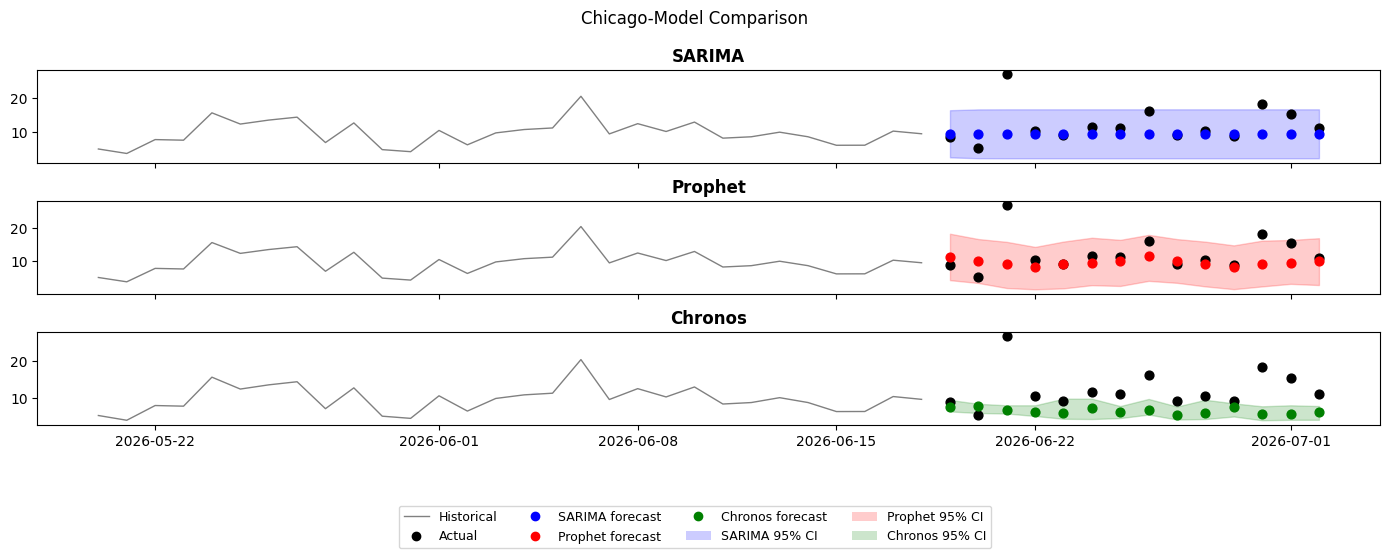

In [22]:
# create custom legend handles
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

## Plotting for Chicago only first

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 5), sharex=True)

# plot last 30 days of training data for context
ax1.plot(chicago_train[-30:].index, chicago_train[-30:].values, 
        color="grey", linewidth=1, label="SARIMA Predictions")

# plot actual test values
ax1.scatter(chicago_test.index, chicago_test.values,
           color="black", zorder=5, s=40, label = "Actual")

#SARIMA
ax1.scatter(chicago_test.index, forecast_sarima_chicago['yhat'],
           color="blue", zorder=5, s=40, label = "Forecasts")
# adding CI
ax1.fill_between(forecast_sarima_chicago["ds"], 
                forecast_sarima_chicago["lower_ci"], 
                forecast_sarima_chicago["upper_ci"], 
                alpha=0.2, color= "blue", label = "95% CI")

ax1.set_title("SARIMA", fontsize=12, fontweight="bold")


ax2.plot(chicago_train[-30:].index, chicago_train[-30:].values, 
        color="grey", linewidth=1, label="Prophet Predictions")

# plot actual test values
ax2.scatter(chicago_test.index, chicago_test.values,
           color="black", zorder=5, label="Actual", s=40)

#SARIMA
ax2.scatter(chicago_test.index, forecast_prophet_chicago['yhat'],
           color="red", zorder=5, s=40,  label = "Forecasts")
# adding CI
ax2.fill_between(forecast_prophet_chicago["ds"], 
                forecast_prophet_chicago["lower_ci"], 
                forecast_prophet_chicago["upper_ci"], 
                alpha=0.2, color= "red")
ax2.set_title("Prophet", fontsize=12, fontweight="bold")


ax3.plot(chicago_train[-30:].index, chicago_train[-30:].values, 
        color="grey", linewidth=1, label="Chronos Predictions")

# plot actual test values
ax3.scatter(chicago_test.index, chicago_test.values,
           color="black", zorder=5, label="Actual", s=40)

# Chronos
ax3.scatter(chicago_test.index, forecast_chronos_chicago['yhat'],
           color="green", zorder=5, s=40, label = "Forecasts")
# adding CI
ax3.fill_between(forecast_chronos_chicago["ds"], 
                forecast_chronos_chicago["lower_ci"], 
                forecast_chronos_chicago["upper_ci"], 
                alpha=0.2, color= "green")
ax3.set_title("Chronos", fontsize=12, fontweight="bold")


legend_elements = [
    Line2D([0], [0], color="grey", linewidth=1, label="Historical"),
    Line2D([0], [0], marker="o", color="black", linewidth=0, markersize=6, label="Actual"),
    Line2D([0], [0], marker="o", color="blue", linewidth=0, markersize=6, label="SARIMA forecast"),
    Line2D([0], [0], marker="o", color="red", linewidth=0, markersize=6, label="Prophet forecast"),
    Line2D([0], [0], marker="o", color="green", linewidth=0, markersize=6, label="Chronos forecast"),
    Patch(facecolor="blue", alpha=0.2, label="SARIMA 95% CI"),
    Patch(facecolor="red", alpha=0.2, label="Prophet 95% CI"),
    Patch(facecolor="green", alpha=0.2, label="Chronos 95% CI"),
]

fig.legend(handles=legend_elements, loc="upper center", 
           bbox_to_anchor=(0.5, 0.0),  # below the figure
           ncol=4, fontsize=9, frameon=True)

plt.suptitle("Chicago-Model Comparison")
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # make room for the legend below
plt.show()


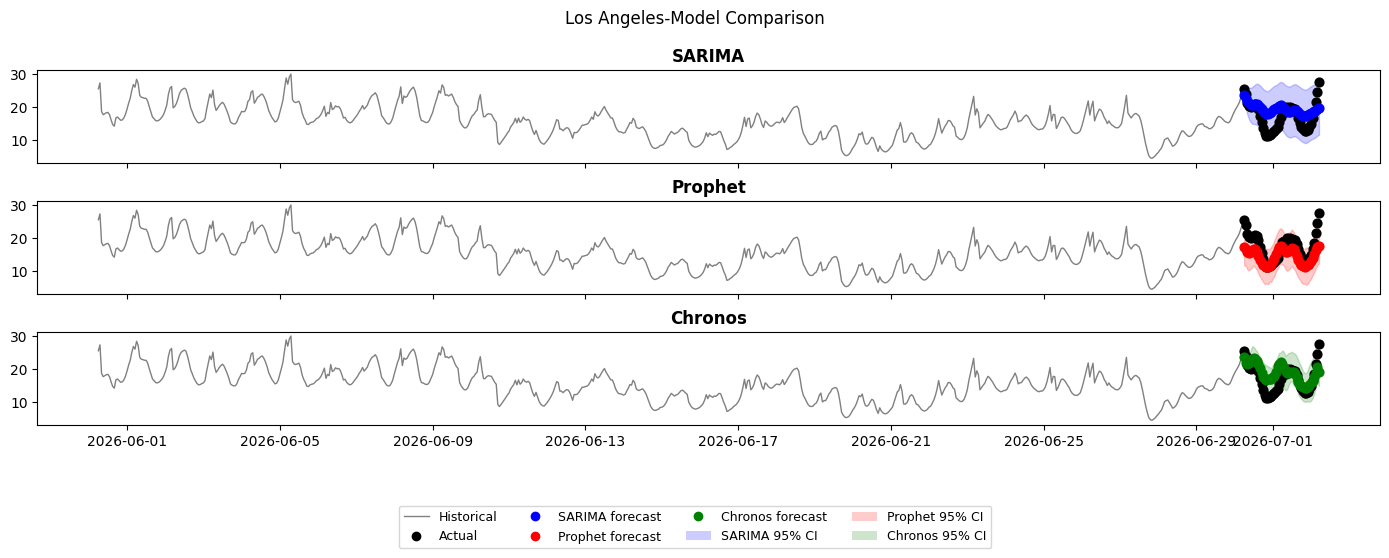

In [23]:
## Plotting for Los Angeles only first

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 5), sharex=True)

# plot last 30 days of training data for context
ax1.plot(la_train[-30*24:].index, la_train[-30*24:].values, 
        color="grey", linewidth=1, label="SARIMA Predictions")

# plot actual test values
ax1.scatter(la_test.index, la_test.values,
           color="black", zorder=5, s=40, label = "Actual")

#SARIMA
ax1.scatter(la_test.index, forecast_sarima_la['yhat'],
           color="blue", zorder=5, s=40, label = "Forecasts")
# adding CI
ax1.fill_between(forecast_sarima_la["ds"], 
                forecast_sarima_la["lower_ci"], 
                forecast_sarima_la["upper_ci"], 
                alpha=0.2, color= "blue", label = "95% CI")

ax1.set_title("SARIMA", fontsize=12, fontweight="bold")


ax2.plot(la_train[-30*24:].index, la_train[-30*24:].values, 
        color="grey", linewidth=1, label="Prophet Predictions")

# plot actual test values
ax2.scatter(la_test.index, la_test.values,
           color="black", zorder=5, label="Actual", s=40)

#SARIMA
ax2.scatter(la_test.index, forecast_prophet_la['yhat'],
           color="red", zorder=5, s=40,  label = "Forecasts")
# adding CI
ax2.fill_between(forecast_prophet_la["ds"], 
                forecast_prophet_la["lower_ci"], 
                forecast_prophet_la["upper_ci"], 
                alpha=0.2, color= "red")
ax2.set_title("Prophet", fontsize=12, fontweight="bold")


ax3.plot(la_train[-30*24:].index, la_train[-30*24:].values, 
        color="grey", linewidth=1, label="Chronos Predictions")

# plot actual test values
ax3.scatter(la_test.index, la_test.values,
           color="black", zorder=5, label="Actual", s=40)

# Chronos
ax3.scatter(la_test.index, forecast_chronos_la['yhat'],
           color="green", zorder=5, s=40, label = "Forecasts")
# adding CI
ax3.fill_between(forecast_chronos_la["ds"], 
                forecast_chronos_la["lower_ci"], 
                forecast_chronos_la["upper_ci"], 
                alpha=0.2, color= "green")
ax3.set_title("Chronos", fontsize=12, fontweight="bold")


legend_elements = [
    Line2D([0], [0], color="grey", linewidth=1, label="Historical"),
    Line2D([0], [0], marker="o", color="black", linewidth=0, markersize=6, label="Actual"),
    Line2D([0], [0], marker="o", color="blue", linewidth=0, markersize=6, label="SARIMA forecast"),
    Line2D([0], [0], marker="o", color="red", linewidth=0, markersize=6, label="Prophet forecast"),
    Line2D([0], [0], marker="o", color="green", linewidth=0, markersize=6, label="Chronos forecast"),
    Patch(facecolor="blue", alpha=0.2, label="SARIMA 95% CI"),
    Patch(facecolor="red", alpha=0.2, label="Prophet 95% CI"),
    Patch(facecolor="green", alpha=0.2, label="Chronos 95% CI"),
]

fig.legend(handles=legend_elements, loc="upper center", 
           bbox_to_anchor=(0.5, 0.0),  # below the figure
           ncol=4, fontsize=9, frameon=True)

plt.suptitle("Los Angeles-Model Comparison")
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # make room for the legend below
plt.show()


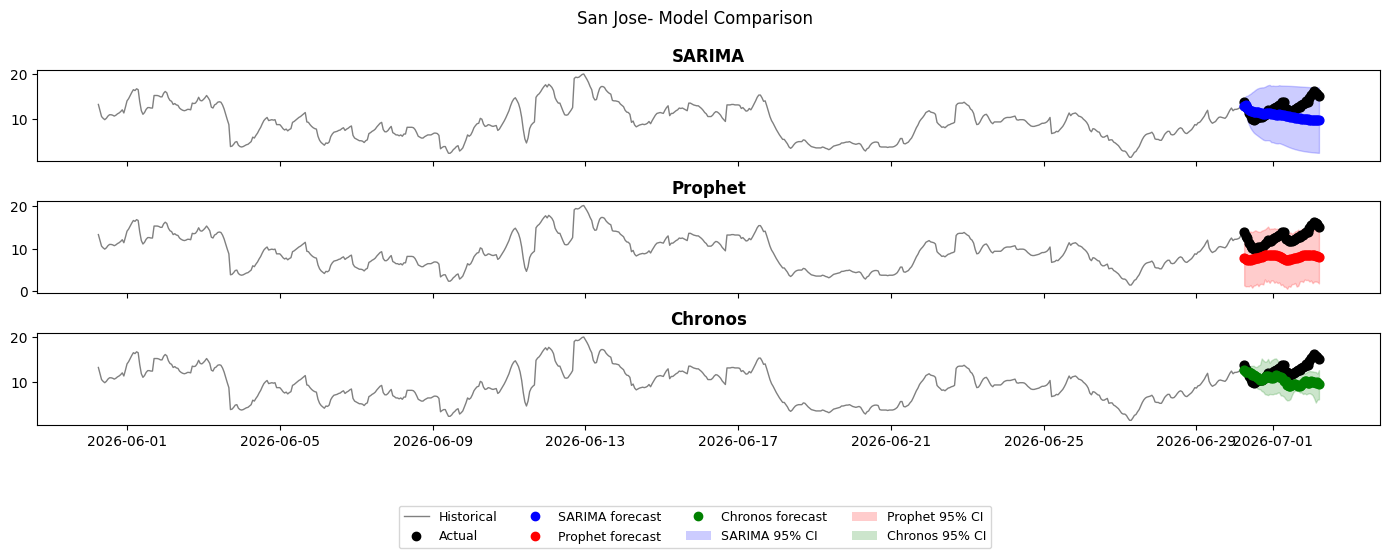

In [24]:
## Plotting for Los Angeles only first

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 5), sharex=True)

# plot last 30 days of training data for context
ax1.plot(sj_train[-30*24:].index, sj_train[-30*24:].values, 
        color="grey", linewidth=1, label="SARIMA Predictions")

# plot actual test values
ax1.scatter(sj_test.index, sj_test.values,
           color="black", zorder=5, s=40, label = "Actual")

#SARIMA
ax1.scatter(sj_test.index, forecast_sarima_sj['yhat'],
           color="blue", zorder=5, s=40, label = "Forecasts")
# adding CI
ax1.fill_between(forecast_sarima_sj["ds"], 
                forecast_sarima_sj["lower_ci"], 
                forecast_sarima_sj["upper_ci"], 
                alpha=0.2, color= "blue", label = "95% CI")

ax1.set_title("SARIMA", fontsize=12, fontweight="bold")


ax2.plot(sj_train[-30*24:].index, sj_train[-30*24:].values, 
        color="grey", linewidth=1, label="Prophet Predictions")

# plot actual test values
ax2.scatter(sj_test.index, sj_test.values,
           color="black", zorder=5, label="Actual", s=40)

#SARIMA
ax2.scatter(sj_test.index, forecast_prophet_sj['yhat'],
           color="red", zorder=5, s=40,  label = "Forecasts")
# adding CI
ax2.fill_between(forecast_prophet_sj["ds"], 
                forecast_prophet_sj["lower_ci"], 
                forecast_prophet_sj["upper_ci"], 
                alpha=0.2, color= "red")
ax2.set_title("Prophet", fontsize=12, fontweight="bold")


ax3.plot(sj_train[-30*24:].index, sj_train[-30*24:].values, 
        color="grey", linewidth=1, label="Chronos Predictions")

# plot actual test values
ax3.scatter(sj_test.index, sj_test.values,
           color="black", zorder=5, label="Actual", s=40)

# Chronos
ax3.scatter(sj_test.index, forecast_chronos_sj['yhat'],
           color="green", zorder=5, s=40, label = "Forecasts")
# adding CI
ax3.fill_between(forecast_chronos_sj["ds"], 
                forecast_chronos_sj["lower_ci"], 
                forecast_chronos_sj["upper_ci"], 
                alpha=0.2, color= "green")
ax3.set_title("Chronos", fontsize=12, fontweight="bold")


legend_elements = [
    Line2D([0], [0], color="grey", linewidth=1, label="Historical"),
    Line2D([0], [0], marker="o", color="black", linewidth=0, markersize=6, label="Actual"),
    Line2D([0], [0], marker="o", color="blue", linewidth=0, markersize=6, label="SARIMA forecast"),
    Line2D([0], [0], marker="o", color="red", linewidth=0, markersize=6, label="Prophet forecast"),
    Line2D([0], [0], marker="o", color="green", linewidth=0, markersize=6, label="Chronos forecast"),
    Patch(facecolor="blue", alpha=0.2, label="SARIMA 95% CI"),
    Patch(facecolor="red", alpha=0.2, label="Prophet 95% CI"),
    Patch(facecolor="green", alpha=0.2, label="Chronos 95% CI"),
]

fig.legend(handles=legend_elements, loc="upper center", 
           bbox_to_anchor=(0.5, 0.0),  # below the figure
           ncol=4, fontsize=9, frameon=True)

plt.suptitle("San Jose- Model Comparison")
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # make room for the legend below
plt.show()


#### Chicago:

* SARIMA has the widest CI band — most uncertain about Chicago's daily volatility
* Prophet and Chronos are tighter but both miss the June 21 spike (26.9 µg/m³) — no model predicted it, consistent with your metrics
* All three cluster around 10 µg/m³ which is the historical mean — safe but uninspiring forecasts

LA:

* All three models track the daily cycle really well — the up/down pattern in the forecasts matches the actual values
* Chronos (green) looks closest to the actual black dots visually — consistent with it winning on RMSE in your metrics table
* Prophet's CI band is tightest — most confident but also misses some peaks

San Jose:

* SARIMA and Chronos track well — forecasts follow the actual pattern closely
* Prophet (red) forecasts too low consistently — that's why its MASE was 13 in the metrics table
* Chronos CI band is very tight — high confidence and good accuracy here

### Anomaly Detection

In [ ]:
chicago_with_anomalies = detect_anomalies(chicago_daily, period = 7)

# Plot figure with tagging is_anomaly
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(chicago_with_anomalies.index, chicago_with_anomalies["value"],
    color="tab:blue", linewidth=1.5, label="AQI value")

anomalies = chicago_with_anomalies[chicago_with_anomalies["is_anomaly"] == True]
ax.scatter(anomalies.index, anomalies["value"],
       color="red", edgecolor="black", s=60, zorder=5, label="Anomaly")

ax.set_xlabel("Timestamp")
ax.set_ylabel("AQI Value")
ax.set_title("Chicago AQI with Detected Anomalies")
ax.legend()
plt.tight_layout()
plt.show()

,timestamp,value,is_raw_outlier,is_res_anomaly,is_anomaly,anomaly_score_standard,anomaly_score_modified
timestamp,,,,,,,
2026-03-30,2026-03-30,7.529167,False,False,False,NaN,NaN
2026-03-31,2026-03-31,9.791667,False,False,False,NaN,NaN
2026-04-01,2026-04-01,4.083333,False,False,False,NaN,NaN
2026-04-02,2026-04-02,7.379167,False,False,False,NaN,NaN
2026-04-03,2026-04-03,10.950000,False,False,False,NaN,NaN
...,...,...,...,...,...,...,...
2026-06-28,2026-06-28,10.300000,False,False,False,NaN,NaN
2026-06-29,2026-06-29,8.937500,False,False,False,NaN,NaN
2026-06-30,2026-06-30,18.283333,False,False,False,NaN,NaN
